# nb11 — Per-PowerBin and per-spaxel kinematics at the wide arc-masked window

The earlier per-PowerBin attempt (nb05x Test 19) and per-spaxel attempts failed:
PowerBin gave noise-blob outer bins at σ > 800 km/s, per-spaxel fits were
too unconstrained. Both used the narrow Ca H+K + G window without
arc-emission masking.

Now we have the **wide arc-masked window** (rest 3800-5400 Å with explicit
z=1.302 source-emission masks) that:
- Collapses SPS spread 26 → 4 km/s
- Reduces the integrated stat error from ±24 → ±6 km/s
- Provides 2.6× more spectral pixels (2161 vs 927 good pixels)

This notebook applies the same pipeline at the wide window to PowerBin and
per-spaxel to see whether the per-bin/per-spaxel measurements are now
**reasonable** (σ in 200-280 km/s range, no noise-blob outliers, σ profile
consistent with the integrated headline σ_e = 254.85 ± 17.87 km/s).

In [1]:
import os, sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

REPO = Path('/Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry')
os.chdir(REPO)
sys.path.insert(0, str(REPO))

from ppxf.ppxf import ppxf
from scripts.run_isource_sweep import load_setup
from scripts.run_window_sweep import (
    _apply_arc_mask, SPS_LAM_RANGE_TEMP, sps_safe_obs_min, Z_SYSTEMIC,
)
from scripts.bootstrap_ppxf import setup_ppxf_inputs_from_spectrum

print('Loading IFU + HST setup...')
state = load_setup()
cube = state['cube']
hdr = state['hdr']
band_mask = state['band_mask']
noise_sky = state['noise_sky']
r_spax = state['r_spax']
arc_spax_mask = state['arc_spax_mask']
R_E = state['R_E']
ny, nx = state['ny'], state['nx']
cx_ifu, cy_ifu = state['cx_ifu'], state['cy_ifu']
print(f'  cube={cube.shape}, R_e={R_E:.3f}", center=({cx_ifu:.1f},{cy_ifu:.1f})')

# Wide arc-masked window: rest 3800-5400 Å (from nb09a sweep)
WLABEL = 'wR3800_5400_arcmask'
LAM_OBS_RANGE = (6367.43, 9048.46)   # rest 3800-5400 at z=0.67564
SPS_LIB = 'fsps'                       # wide window collapses SPS spread to 4 km/s
DEGREES = np.arange(15, 30)
PPXF_DEGREE = 22                       # middle of stable range
print(f'Window: {WLABEL}  obs={LAM_OBS_RANGE}  SPS={SPS_LIB}')


Loading IFU + HST setup...
[setup] Loading IFU cube...


[setup] cube shape=(3317, 100, 100)  pix=0.300"/spax
[setup] Loading HST F140W and F200LP ...


[setup] HST_mean center → IFU sub-pixel (50.147, 54.264)
[setup] arc_spax_mask (F200 raw): 69 / 10000 (0.69%)
[setup] spaxel_masked (PSF-aware F140W): 198 / 10000 (1.98%)
[setup] R_e = mean(2.168, 2.441) = 2.305"
  cube=(3317, 100, 100), R_e=2.305", center=(50.1,54.3)
Window: wR3800_5400_arcmask  obs=(6367.43, 9048.46)  SPS=fsps


## §1 — Per-spaxel S/N map and fitting selection

Aperture: R<1.5R_e=3.46", non-arc-masked, positive flux → 358 spaxels
  per-spaxel S/N at 6500-7500: min=0.14  max=7.41  median=1.15
  total capacity within aperture: 1842.2 (= S/N^2 of co-added aperture spectrum)


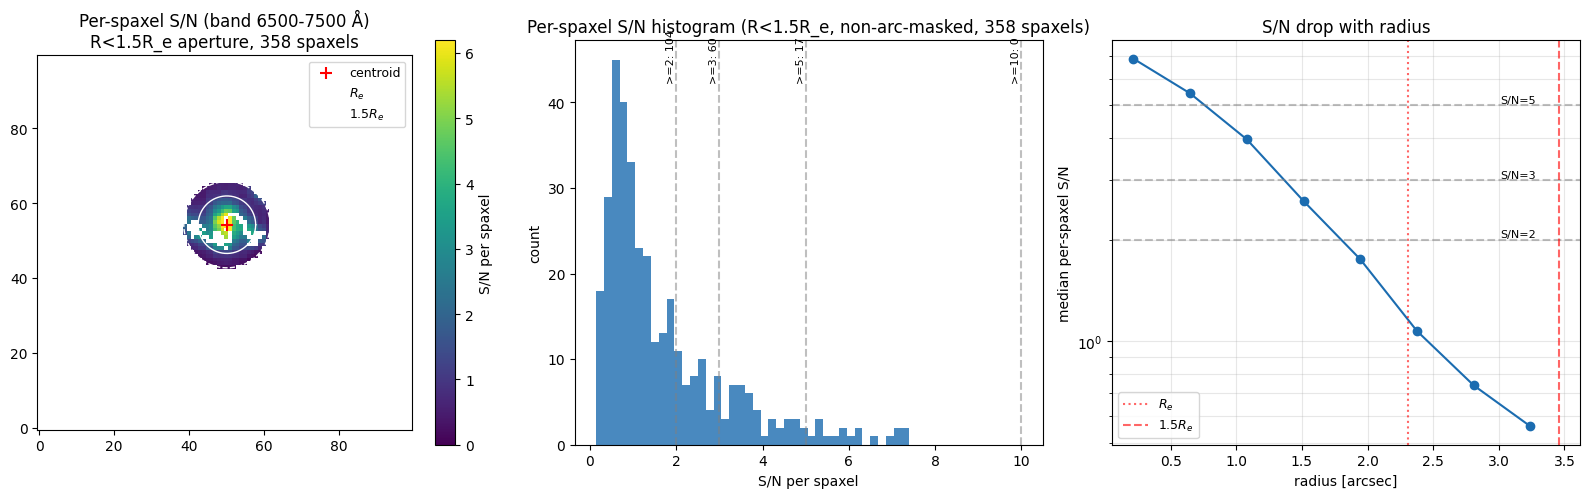

In [2]:
# Per-spaxel band-integrated S/N at 6500-7500 Å (the canonical S/N band)
# to inform PowerBin capacity and per-spaxel S/N floor cuts.
flux_band = np.median(cube[band_mask], axis=0)        # per-spaxel median flux
noise_band_median = float(np.median(noise_sky[band_mask]))   # scalar noise

# The cube noise is sky-only; per-spaxel S/N proxy uses single-spaxel noise.
# Capacity = S/N^2 so co-adding spaxels gives S/N_combined = sqrt(sum(cap)).
sn_spax = flux_band / max(noise_band_median, 1e-30)
sn_spax = np.where(np.isfinite(sn_spax), sn_spax, 0.0)
cap_spax = sn_spax**2

# APERTURE: R < 1.5 R_e (smaller than 3R_e — the outer region is too noise-dominated
# for per-spaxel ppxf, and the 1.5 R_e cap matches where per-spaxel is reliable)
R_MAX_FACTOR = 1.5
R_MAX = R_MAX_FACTOR * R_E
sel_aperture = (r_spax < R_MAX) & (~arc_spax_mask) & (flux_band > 0)
n_sel = int(sel_aperture.sum())
print(f'Aperture: R<{R_MAX_FACTOR}R_e={R_MAX:.2f}", non-arc-masked, positive flux → {n_sel} spaxels')
print(f'  per-spaxel S/N at 6500-7500: min={sn_spax[sel_aperture].min():.2f}  '
      f'max={sn_spax[sel_aperture].max():.2f}  median={np.median(sn_spax[sel_aperture]):.2f}')
print(f'  total capacity within aperture: {cap_spax[sel_aperture].sum():.1f} '
      f'(= S/N^2 of co-added aperture spectrum)')

# How does S/N drop with radius?
r_bin_edges = np.linspace(0, R_MAX, 9)
r_centers = 0.5 * (r_bin_edges[:-1] + r_bin_edges[1:])
sn_in_rbin = []
for lo, hi in zip(r_bin_edges[:-1], r_bin_edges[1:]):
    sel = sel_aperture & (r_spax >= lo) & (r_spax < hi)
    sn_in_rbin.append(np.median(sn_spax[sel]) if sel.any() else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax = axes[0]
im = ax.imshow(np.where(sel_aperture, sn_spax, np.nan), origin='lower',
                cmap='viridis', vmin=0, vmax=np.nanpercentile(sn_spax[sel_aperture], 98))
ax.scatter([cx_ifu], [cy_ifu], marker='+', color='red', s=80, label='centroid')
# R_e and 1.5 R_e rings
theta = np.linspace(0, 2*np.pi, 200)
for r_circ, ls, lbl in ((R_E, '-', r'$R_e$'), (R_MAX, '--', rf'${R_MAX_FACTOR}R_e$')):
    rpix = r_circ / 0.30
    ax.plot(cx_ifu + rpix*np.cos(theta), cy_ifu + rpix*np.sin(theta),
            ls=ls, color='white', lw=1.0, label=lbl)
plt.colorbar(im, ax=ax, label='S/N per spaxel')
ax.set_title(f'Per-spaxel S/N (band 6500-7500 Å)\nR<{R_MAX_FACTOR}R_e aperture, {n_sel} spaxels')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
ax.hist(sn_spax[sel_aperture], bins=40, color='#1b6cb0', alpha=0.8)
ax.set_xlabel('S/N per spaxel'); ax.set_ylabel('count')
for thresh in (2, 3, 5, 10):
    n_above = int((sn_spax[sel_aperture] >= thresh).sum())
    ax.axvline(thresh, color='gray', ls='--', alpha=0.5)
    ax.text(thresh, ax.get_ylim()[1]*0.9, f'>={thresh}: {n_above}',
            rotation=90, ha='right', fontsize=8)
ax.set_title(f'Per-spaxel S/N histogram (R<{R_MAX_FACTOR}R_e, non-arc-masked, {n_sel} spaxels)')

ax = axes[2]
ax.plot(r_centers, sn_in_rbin, '-o', color='#1b6cb0')
for thresh in (2, 3, 5):
    ax.axhline(thresh, color='gray', ls='--', alpha=0.5)
    ax.text(R_MAX*0.95, thresh, f'S/N={thresh}', ha='right', va='bottom', fontsize=8)
ax.axvline(R_E, color='red', ls=':', alpha=0.6, label=r'$R_e$')
ax.axvline(R_MAX, color='red', ls='--', alpha=0.6, label=rf'${R_MAX_FACTOR}R_e$')
ax.set_xlabel('radius [arcsec]'); ax.set_ylabel('median per-spaxel S/N')
ax.set_yscale('log')
ax.set_title('S/N drop with radius')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig(REPO / 'results/figures/nb11_perspaxel_sn.png', dpi=140)
plt.show()


## §2 — PowerBin spatial binning

PowerBin co-adds spaxels until each bin reaches a target S/N. Co-added
S/N = sqrt(sum of capacities). We target S/N=10 per bin — high enough for
σ measurement to a few × 10 km/s precision, low enough to give ~20-40 bins
across the deflector.

In [3]:
from powerbin import PowerBin

TARGET_SN = 15.0   # bumped from 10 to 15 to reduce noise-blob outer bins
target_cap = TARGET_SN**2

# PowerBin inputs: xy coords (in spaxels) and capacity (S/N^2) for selected spaxels
yy, xx = np.mgrid[:ny, :nx]
sel_pb = sel_aperture & (sn_spax > 0)
xy_pb = np.column_stack([xx[sel_pb], yy[sel_pb]]).astype(float)
cap_pb = cap_spax[sel_pb]
print(f'PowerBin input: {sel_pb.sum()} spaxels, total capacity = {cap_pb.sum():.1f}')
print(f'Target S/N = {TARGET_SN} (capacity = {target_cap}) → expect ~{int(cap_pb.sum()/target_cap)} bins')

pb = PowerBin(xy_pb, cap_pb, target_capacity=target_cap,
              pixelsize=1.0, verbose=0)
bin_ids = pb.bin_num
n_bins = int(bin_ids.max()) + 1
print(f'PowerBin produced {n_bins} bins  (median pixels/bin = {np.median(pb.npix):.0f}, RMS S/N scatter = {pb.rms_frac:.1f}%)')

# Map bin_id back to (ny, nx) grid
bin_map = -np.ones((ny, nx), dtype=int)
y_pb_arr = yy[sel_pb]
x_pb_arr = xx[sel_pb]
for k in range(len(bin_ids)):
    bin_map[y_pb_arr[k], x_pb_arr[k]] = bin_ids[k]

# Per-bin centroid (mean spaxel position), total capacity, S/N, radius
bin_centroids = np.zeros((n_bins, 2))
bin_cap = np.zeros(n_bins)
bin_n_spax = np.zeros(n_bins, dtype=int)
bin_r_arcsec = np.zeros(n_bins)
for b in range(n_bins):
    mask = bin_map == b
    bin_centroids[b] = (xx[mask].mean(), yy[mask].mean())
    bin_cap[b] = cap_spax[mask].sum()
    bin_n_spax[b] = int(mask.sum())
    bin_r_arcsec[b] = float(np.median(r_spax[mask]))

bin_sn = np.sqrt(bin_cap)
print(f'Per-bin S/N: median={np.median(bin_sn):.1f}, min={bin_sn.min():.1f}, max={bin_sn.max():.1f}')
print(f'Per-bin N_spax: median={int(np.median(bin_n_spax))}, min={bin_n_spax.min()}, max={bin_n_spax.max()}')


PowerBin input: 358 spaxels, total capacity = 1842.2
Target S/N = 15.0 (capacity = 225.0) → expect ~8 bins
PowerBin produced 7 bins  (median pixels/bin = 64, RMS S/N scatter = 35.7%)
Per-bin S/N: median=15.5, min=13.2, max=20.0
Per-bin N_spax: median=64, min=13, max=75


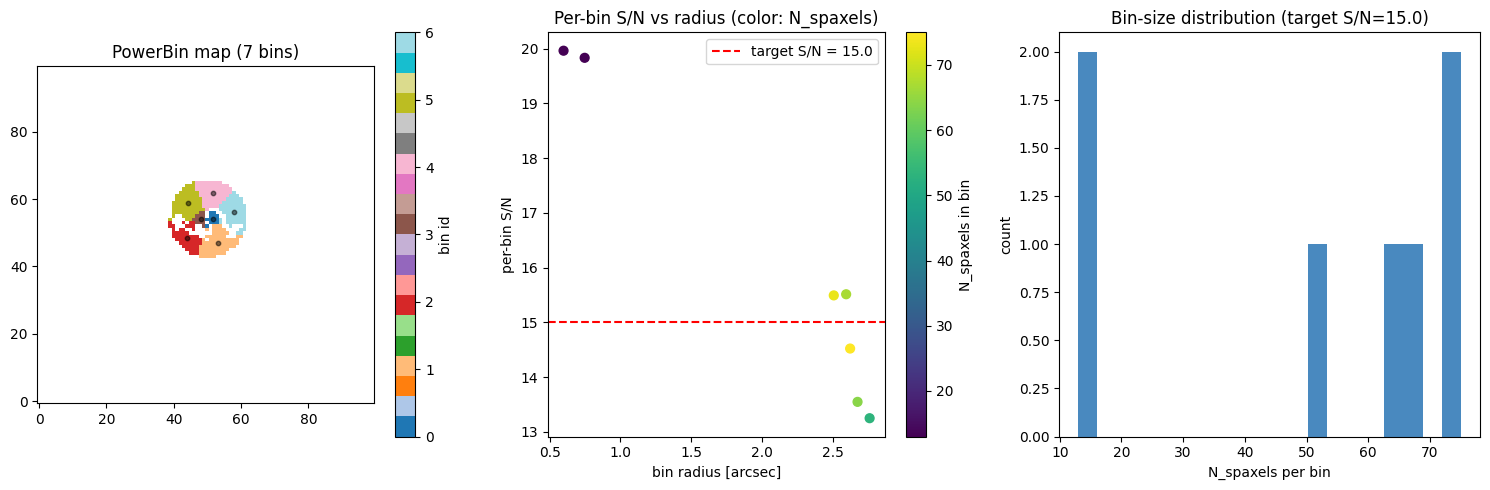

In [4]:
# PowerBin map figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes[0]
bin_map_show = np.where(bin_map >= 0, bin_map.astype(float), np.nan)
im = ax.imshow(bin_map_show, origin='lower', cmap='tab20', interpolation='nearest')
ax.scatter(*zip(*bin_centroids), marker='o', s=10, color='black', alpha=0.5)
ax.set_title(f'PowerBin map ({n_bins} bins)')
plt.colorbar(im, ax=ax, label='bin id')

ax = axes[1]
ax.scatter(bin_r_arcsec, bin_sn, c=bin_n_spax, cmap='viridis', s=40)
ax.axhline(TARGET_SN, color='red', ls='--', label=f'target S/N = {TARGET_SN}')
ax.set_xlabel('bin radius [arcsec]'); ax.set_ylabel('per-bin S/N')
ax.set_title('Per-bin S/N vs radius (color: N_spaxels)')
plt.colorbar(ax.collections[0], ax=ax, label='N_spaxels in bin')
ax.legend()

ax = axes[2]
ax.hist(bin_n_spax, bins=20, color='#1b6cb0', alpha=0.8)
ax.set_xlabel('N_spaxels per bin'); ax.set_ylabel('count')
ax.set_title(f'Bin-size distribution (target S/N={TARGET_SN})')
plt.tight_layout()
fig.savefig(REPO / 'results/figures/nb11_powerbin_map.png', dpi=140)
plt.show()


## §3 — Per-PowerBin ppxf at the wide arc-masked window

Each bin gets its co-added spectrum, then ppxf at the wide arc-masked
window. We use FSPS templates (single SPS — wide window has SPS spread of
4 km/s, sub-stat for any per-bin measurement) and degree=22 polynomial.

In [5]:
def fit_one_spectrum(flux, noise_spec, *, sps_name=SPS_LIB, lam_obs_range=LAM_OBS_RANGE,
                      z=Z_SYSTEMIC, degree=PPXF_DEGREE, quiet=True):
    '''Run ppxf at the wide arc-masked window. Returns dict with V, sigma, chi2, bestfit.'''
    lr_eff = (max(lam_obs_range[0], sps_safe_obs_min(sps_name)), lam_obs_range[1])
    inputs = setup_ppxf_inputs_from_spectrum(
        flux, noise_spec, hdr, sps_name=sps_name, z=z,
        lam_obs_range=lr_eff, lam_fit_range=lr_eff,
        lam_range_temp=SPS_LAM_RANGE_TEMP[sps_name],
        verbose=False, frame_galaxy='auto',
    )
    inputs['goodpixels'] = _apply_arc_mask(inputs['goodpixels'], inputs['lam_gal_rest'])
    pp = ppxf(
        inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
        inputs['velscale'], inputs['start'],
        goodpixels=inputs['goodpixels'], plot=False, moments=2,
        trig=False, degree=int(degree), mdegree=0,
        lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=quiet,
    )
    return dict(V=pp.sol[0], sigma=pp.sol[1], chi2=pp.chi2,
                bestfit=pp.bestfit, galaxy=inputs['galaxy'],
                lam_rest=inputs['lam_gal_rest'],
                goodpixels=inputs['goodpixels'])

print(f'Running ppxf on {n_bins} PowerBin bins at the wide arc-masked window...')
t0 = time.time()
bin_results = []
for b in range(n_bins):
    mask = bin_map == b
    # Co-add spaxels in this bin (simple sum — equal weighting)
    flux_b = np.sum(cube[:, mask], axis=1)
    # Noise: sky-only noise scaled by sqrt(N_spax) for unweighted sum
    n_spax = int(mask.sum())
    noise_b = noise_sky * np.sqrt(n_spax)
    try:
        r = fit_one_spectrum(flux_b, noise_b)
        bin_results.append({'bin_id': b, 'n_spax': n_spax, 'sn': float(bin_sn[b]),
                             'r_arcsec': float(bin_r_arcsec[b]),
                             'V': float(r['V']), 'sigma': float(r['sigma']),
                             'chi2': float(r['chi2'])})
    except Exception as e:
        print(f'  bin {b}: FAILED {type(e).__name__}: {e}')
        bin_results.append({'bin_id': b, 'n_spax': n_spax, 'sn': float(bin_sn[b]),
                             'r_arcsec': float(bin_r_arcsec[b]),
                             'V': np.nan, 'sigma': np.nan, 'chi2': np.nan})
elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s ({elapsed/n_bins:.1f}s/bin)')

# Pull arrays
bV = np.array([r['V'] for r in bin_results])
bSig = np.array([r['sigma'] for r in bin_results])
bChi2 = np.array([r['chi2'] for r in bin_results])
bR = np.array([r['r_arcsec'] for r in bin_results])
bSN = np.array([r['sn'] for r in bin_results])
bN = np.array([r['n_spax'] for r in bin_results])

print()
print(f'Per-bin sigma summary:')
print(f'  median = {np.nanmedian(bSig):.1f} km/s')
print(f'  min/max = {np.nanmin(bSig):.1f} / {np.nanmax(bSig):.1f} km/s')
print(f'  N > 400 km/s (unphysical / noise blob): {int((bSig > 400).sum())} / {n_bins}')
print(f'  N < 100 km/s (suspicious / instrumental): {int((bSig < 100).sum())} / {n_bins}')
print()
print(f'Per-bin V summary:')
Vsys = float(np.nanmedian(bV[bR < 1.0])) if (bR < 1.0).any() else float(np.nanmedian(bV))
print(f'  central V_sys (median V at R<1") = {Vsys:.1f} km/s')
print(f'  V - V_sys: min={(bV-Vsys).min():+.0f}  max={(bV-Vsys).max():+.0f}')


Running ppxf on 7 PowerBin bins at the wide arc-masked window...


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

Done in 4.4s (0.6s/bin)

Per-bin sigma summary:
  median = 294.5 km/s
  min/max = 220.3 / 440.4 km/s
  N > 400 km/s (unphysical / noise blob): 2 / 7
  N < 100 km/s (suspicious / instrumental): 0 / 7

Per-bin V summary:
  central V_sys (median V at R<1") = -15.5 km/s
  V - V_sys: min=-272  max=+154


## §4 — PowerBin σ and V maps + radial profile

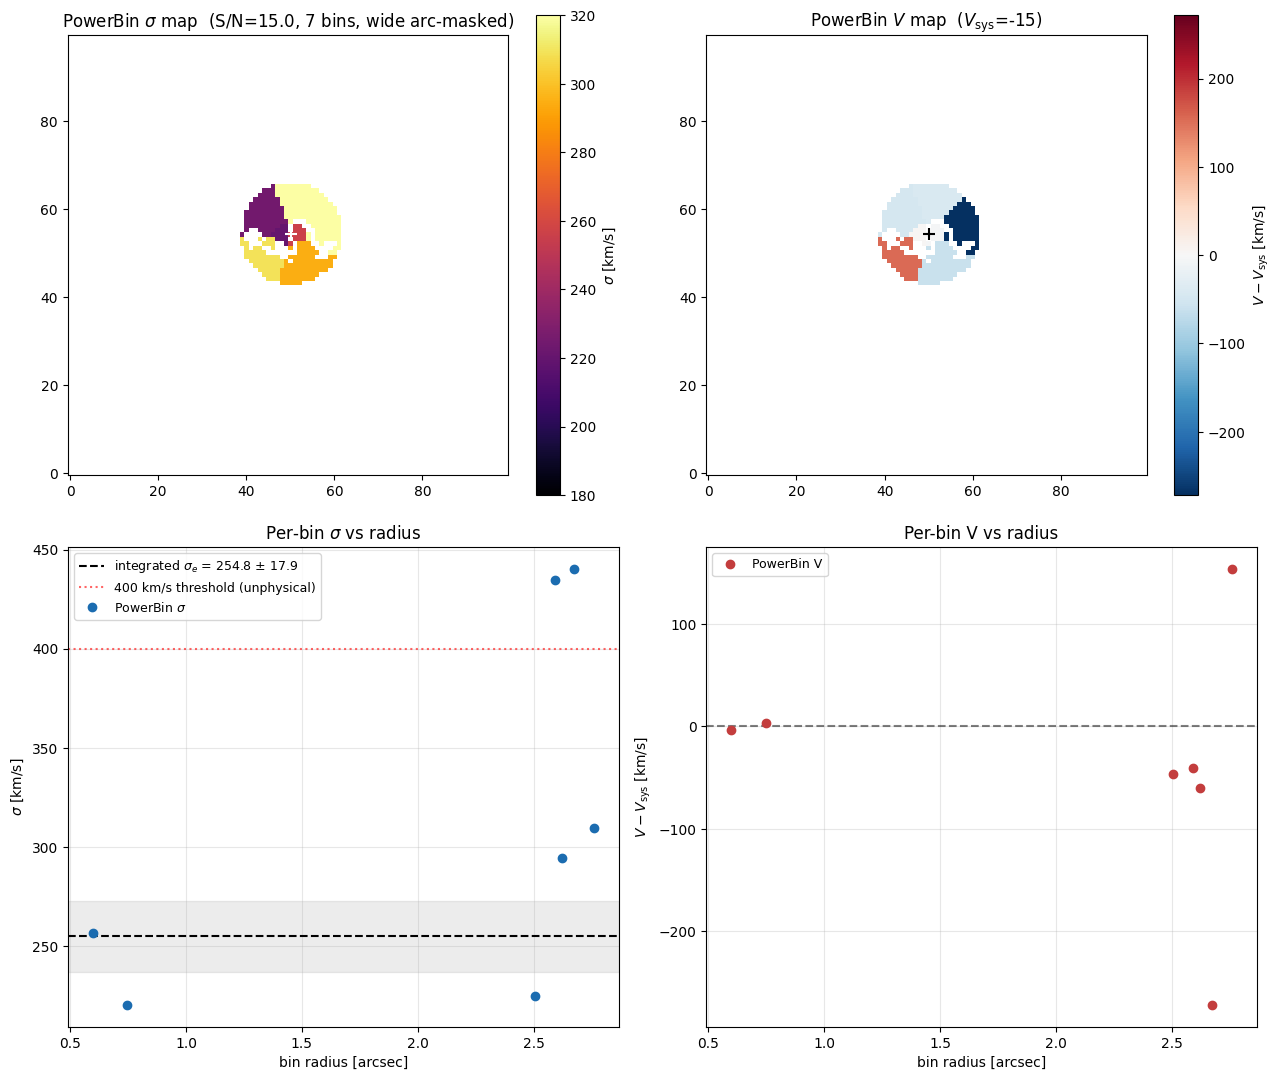

In [6]:
# Reconstruct 2D maps by painting each bin's value onto its spaxels
sigma_map = np.full((ny, nx), np.nan)
V_map = np.full((ny, nx), np.nan)
for b in range(n_bins):
    mask = bin_map == b
    sigma_map[mask] = bSig[b]
    V_map[mask] = bV[b] - Vsys

# Headline (integrated) value for reference
sigma_headline = 254.85
sigma_headline_err = 17.87

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
ax = axes[0, 0]
im = ax.imshow(sigma_map, origin='lower', cmap='inferno', vmin=180, vmax=320)
ax.scatter([cx_ifu], [cy_ifu], marker='+', color='white', s=80)
plt.colorbar(im, ax=ax, label=r'$\sigma$ [km/s]')
ax.set_title(rf'PowerBin $\sigma$ map  (S/N={TARGET_SN}, {n_bins} bins, wide arc-masked)')

ax = axes[0, 1]
vmax = float(np.nanmax(np.abs(V_map))) if np.isfinite(V_map).any() else 100
im = ax.imshow(V_map, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.scatter([cx_ifu], [cy_ifu], marker='+', color='black', s=80)
plt.colorbar(im, ax=ax, label=r'$V - V_{\rm sys}$ [km/s]')
ax.set_title(rf'PowerBin $V$ map  ($V_{{\rm sys}}$={Vsys:.0f})')

ax = axes[1, 0]
ax.errorbar(bR, bSig, fmt='o', ms=6, color='#1b6cb0',
            label=r'PowerBin $\sigma$')
ax.axhline(sigma_headline, color='black', ls='--',
           label=rf'integrated $\sigma_e$ = {sigma_headline:.1f} $\pm$ {sigma_headline_err:.1f}')
ax.axhspan(sigma_headline-sigma_headline_err, sigma_headline+sigma_headline_err,
           color='gray', alpha=0.15)
ax.axhline(400, color='red', ls=':', alpha=0.6, label='400 km/s threshold (unphysical)')
ax.set_xlabel('bin radius [arcsec]')
ax.set_ylabel(r'$\sigma$ [km/s]')
ax.set_title(r'Per-bin $\sigma$ vs radius')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.errorbar(bR, bV - Vsys, fmt='o', ms=6, color='#c33d3d',
            label=r'PowerBin V')
ax.axhline(0, color='black', ls='--', alpha=0.5)
ax.set_xlabel('bin radius [arcsec]')
ax.set_ylabel(r'$V - V_{\rm sys}$ [km/s]')
ax.set_title(r'Per-bin V vs radius')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(REPO / 'results/figures/nb11_powerbin_kinematics.png', dpi=140)
plt.show()


## §5 — Per-spaxel ppxf for high-S/N spaxels only

Per-spaxel ppxf at the wide window is feasible only where per-spaxel S/N is
high enough (>~5). Most spaxels in the aperture have S/N < 2 — ppxf would
give wildly uncertain σ there. We fit only spaxels with S/N >= 5 and report
σ values vs radius. Expectation: only the central few spaxels qualify.

In [7]:
# Per-spaxel ppxf at multiple S/N floors so we can see where the per-spaxel
# measurement breaks down inside the expanded R<3R_e aperture.
SN_FLOORS = [10.0, 5.0, 3.0, 2.0]

sp_runs = {}
for sn_floor in SN_FLOORS:
    spax_sel = sel_aperture & (sn_spax >= sn_floor)
    n_spax_fit = int(spax_sel.sum())
    print(f'\n--- Per-spaxel fit at S/N >= {sn_floor}: {n_spax_fit} spaxels ---')
    if n_spax_fit == 0:
        sp_runs[sn_floor] = dict(n=0, y=np.array([]), x=np.array([]),
                                 r=np.array([]), sn=np.array([]),
                                 V=np.array([]), sigma=np.array([]),
                                 chi2=np.array([]))
        continue

    ys_fit, xs_fit = np.where(spax_sel)
    rec = []
    t0 = time.time()
    for y, x in zip(ys_fit, xs_fit):
        try:
            r = fit_one_spectrum(cube[:, y, x], noise_sky.copy())
            rec.append((y, x, float(r_spax[y, x]), float(sn_spax[y, x]),
                        float(r['V']), float(r['sigma']), float(r['chi2'])))
        except Exception as e:
            rec.append((y, x, float(r_spax[y, x]), float(sn_spax[y, x]),
                        np.nan, np.nan, np.nan))
    elapsed = time.time() - t0
    rec = np.array(rec)
    print(f'  ppxf in {elapsed:.1f}s ({elapsed/n_spax_fit:.2f}s/spaxel)')
    sp_runs[sn_floor] = dict(
        n=n_spax_fit,
        y=rec[:, 0].astype(int),
        x=rec[:, 1].astype(int),
        r=rec[:, 2],
        sn=rec[:, 3],
        V=rec[:, 4],
        sigma=rec[:, 5],
        chi2=rec[:, 6],
    )

    sig = rec[:, 5]
    sig_finite = sig[np.isfinite(sig)]
    n_inrange = int(((sig_finite >= 150) & (sig_finite <= 350)).sum())
    n_unphys = int((sig_finite > 400).sum())
    n_low = int((sig_finite < 100).sum())
    print(f'  σ summary: median={np.nanmedian(sig):.1f}, '
          f'min/max={np.nanmin(sig):.1f}/{np.nanmax(sig):.1f}')
    print(f'  σ in [150,350]: {n_inrange}/{n_spax_fit}  '
          f'σ>400: {n_unphys}  σ<100: {n_low}')

# Headline reference set from the strict S/N>=5 run (clean) for downstream cells
spR = sp_runs[5.0]['r']
spV = sp_runs[5.0]['V']
spSig = sp_runs[5.0]['sigma']
spSN = sp_runs[5.0]['sn']
sp_records = [dict(y=int(sp_runs[5.0]['y'][k]), x=int(sp_runs[5.0]['x'][k]),
                    r_arcsec=float(sp_runs[5.0]['r'][k]), sn=float(sp_runs[5.0]['sn'][k]),
                    V=float(sp_runs[5.0]['V'][k]), sigma=float(sp_runs[5.0]['sigma'][k]),
                    chi2=float(sp_runs[5.0]['chi2'][k]))
              for k in range(sp_runs[5.0]['n'])]
n_spax_fit = sp_runs[5.0]['n']
SN_FLOOR_SPAXEL = 5.0   # headline floor for §6 / npz



--- Per-spaxel fit at S/N >= 10.0: 0 spaxels ---

--- Per-spaxel fit at S/N >= 5.0: 17 spaxels ---


  ppxf in 9.2s (0.54s/spaxel)
  σ summary: median=201.0, min/max=143.9/250.7
  σ in [150,350]: 16/17  σ>400: 0  σ<100: 0

--- Per-spaxel fit at S/N >= 3.0: 60 spaxels ---


  ppxf in 34.0s (0.57s/spaxel)
  σ summary: median=221.0, min/max=0.4/1000.0
  σ in [150,350]: 38/60  σ>400: 13  σ<100: 5

--- Per-spaxel fit at S/N >= 2.0: 104 spaxels ---


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:802: RuntimeWarning: invalid value encountered in scalar divide
  ratio = actred/prered


  ppxf in 63.9s (0.61s/spaxel)
  σ summary: median=224.8, min/max=0.4/1000.0
  σ in [150,350]: 52/104  σ>400: 28  σ<100: 14


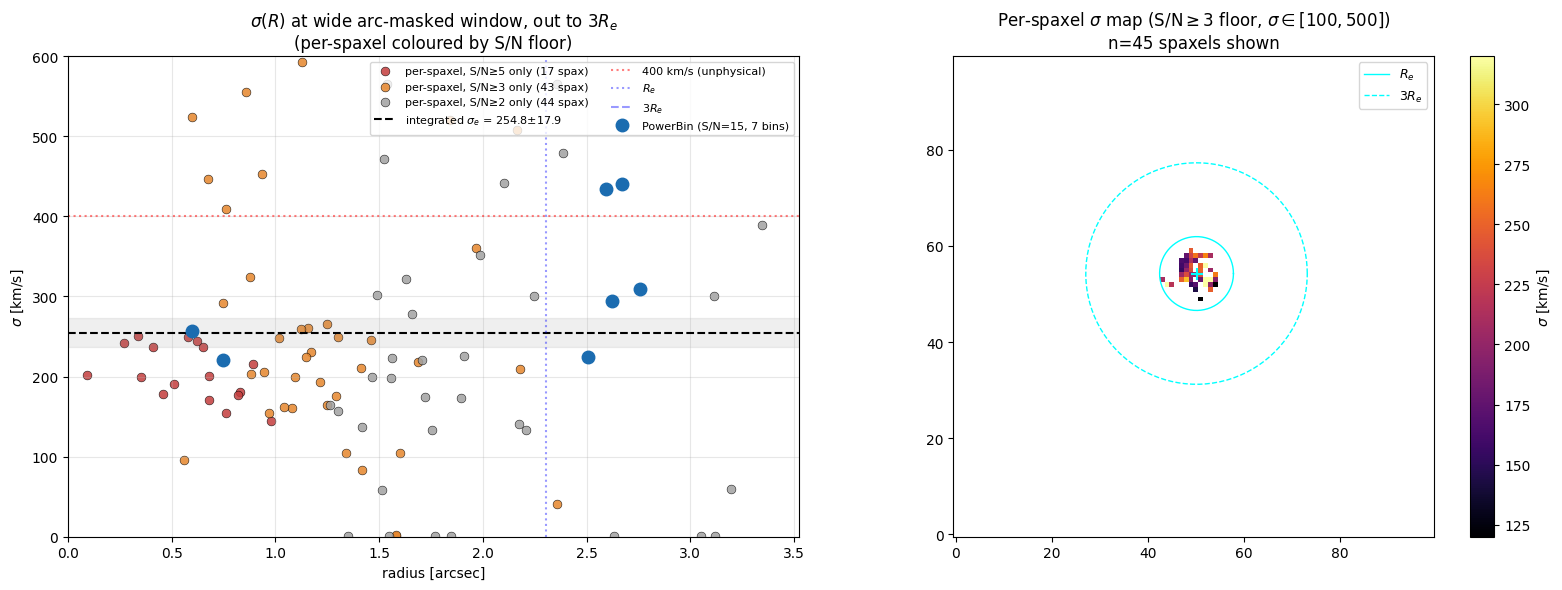

In [8]:
# Combined σ(R) showing PowerBin + per-spaxel at multiple S/N floors,
# and 2D σ map from the relaxed-floor per-spaxel run.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: σ vs R overlay
ax = axes[0]
ax.errorbar(bR, bSig, fmt='o', ms=9, color='#1b6cb0',
            label=f'PowerBin (S/N={TARGET_SN:.0f}, {n_bins} bins)')

SN_COLORS = {10.0: '#222', 5.0: '#c33d3d', 3.0: '#e6862c', 2.0: '#a1a1a1'}
for sn_floor in (10.0, 5.0, 3.0, 2.0):
    rr = sp_runs[sn_floor]
    if rr['n'] == 0:
        continue
    # only-this-floor: spaxels at this floor that were NOT in the previous tighter floor
    finer_floors = [s for s in SN_FLOORS if s > sn_floor]
    if finer_floors:
        prev_n = sp_runs[min(finer_floors)]['n']  # tightest stricter floor
        new_idx = slice(prev_n, rr['n']) if prev_n < rr['n'] else slice(0, 0)
    else:
        new_idx = slice(0, rr['n'])
    # but rr arrays aren't sorted by S/N, so use direct boolean mask
    if finer_floors:
        prev_floor = min(finer_floors)
        only_this = rr['sn'] < prev_floor   # not in the stricter run
    else:
        only_this = np.ones(rr['n'], dtype=bool)
    sig_only = rr['sigma'][only_this]
    r_only = rr['r'][only_this]
    ax.scatter(r_only, sig_only, s=40, color=SN_COLORS[sn_floor],
               edgecolor='black', linewidth=0.4, alpha=0.85,
               label=f'per-spaxel, S/N≥{sn_floor:.0f} only ({int(only_this.sum())} spax)')

ax.axhline(sigma_headline, color='black', ls='--',
           label=rf'integrated $\sigma_e$ = {sigma_headline:.1f}$\pm${sigma_headline_err:.1f}')
ax.axhspan(sigma_headline - sigma_headline_err, sigma_headline + sigma_headline_err,
           color='gray', alpha=0.12)
ax.axhline(400, color='red', ls=':', alpha=0.5, label='400 km/s (unphysical)')
ax.axvline(R_E, color='blue', ls=':', alpha=0.4, label=r'$R_e$')
ax.axvline(3*R_E, color='blue', ls='--', alpha=0.4, label=r'$3R_e$')
ax.set_xlabel('radius [arcsec]'); ax.set_ylabel(r'$\sigma$ [km/s]')
ax.set_title(r'$\sigma(R)$ at wide arc-masked window, out to $3R_e$' + '\n(per-spaxel coloured by S/N floor)')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(alpha=0.3)
ax.set_xlim(0, R_MAX * 1.02)
ax.set_ylim(0, 600)

# Right: per-spaxel σ map (using S/N>=3 to extend coverage)
ax = axes[1]
sigma_perspax_map = np.full((ny, nx), np.nan)
rr3 = sp_runs[3.0]
for k in range(rr3['n']):
    if np.isfinite(rr3['sigma'][k]) and 100 < rr3['sigma'][k] < 500:
        sigma_perspax_map[rr3['y'][k], rr3['x'][k]] = rr3['sigma'][k]
im = ax.imshow(sigma_perspax_map, origin='lower', cmap='inferno', vmin=120, vmax=320)
ax.scatter([cx_ifu], [cy_ifu], marker='+', color='cyan', s=80)
# R_e and 3R_e rings
theta = np.linspace(0, 2*np.pi, 200)
for r_circ, ls, lbl in ((R_E, '-', r'$R_e$'), (3*R_E, '--', r'$3R_e$')):
    rpix = r_circ / 0.30
    ax.plot(cx_ifu + rpix*np.cos(theta), cy_ifu + rpix*np.sin(theta),
            ls=ls, color='cyan', lw=1.0, label=lbl)
plt.colorbar(im, ax=ax, label=r'$\sigma$ [km/s]')
ax.set_title(r'Per-spaxel $\sigma$ map (S/N$\geq$3 floor, $\sigma\in[100,500]$)' +
             f'\nn={int(np.isfinite(sigma_perspax_map).sum())} spaxels shown')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
fig.savefig(REPO / 'results/figures/nb11_perbin_perspaxel_sigma_vs_r.png', dpi=140)
plt.show()


## §6 — Reasonableness verdict + save

In [9]:
print('=' * 70)
print(f'REASONABLENESS CHECK at wide arc-masked window, R<{R_MAX_FACTOR}R_e aperture')
print('=' * 70)
pb_inrange = int(((bSig >= 150) & (bSig <= 350)).sum())
pb_unphys = int((bSig > 400).sum())
print(f'PowerBin (target S/N={TARGET_SN:.0f}): {n_bins} bins')
print(f'  σ in [150, 350] km/s: {pb_inrange} / {n_bins}  ({100*pb_inrange/n_bins:.0f}%)')
print(f'  σ > 400 km/s (unphysical): {pb_unphys} / {n_bins}  ({100*pb_unphys/n_bins:.0f}%)')
print(f'  median σ = {np.nanmedian(bSig):.1f} km/s  (vs headline {sigma_headline:.1f})')
print()
print('Per-spaxel at different S/N floors:')
print(f'{"S/N floor":<12}{"N spaxels":>11}{"% in [150,350]":>17}{"N > 400":>10}{"median σ":>14}')
print('-' * 64)
for sn_floor in SN_FLOORS:
    rr = sp_runs[sn_floor]
    if rr['n'] == 0:
        print(f'{sn_floor:<12.1f}{rr["n"]:>11d}    --')
        continue
    sig = rr['sigma']; sig_f = sig[np.isfinite(sig)]
    n_in = int(((sig_f >= 150) & (sig_f <= 350)).sum())
    n_un = int((sig_f > 400).sum())
    print(f'{sn_floor:<12.1f}{rr["n"]:>11d}{100*n_in/rr["n"]:>15.0f}%   '
          f'{n_un:>8d}{np.nanmedian(sig):>14.1f}')
print()
print(f'Interpretation (R < {R_MAX_FACTOR} R_e = {R_MAX:.2f}"):')
print('  - Per-spaxel works cleanly at S/N >= 5 (all spaxels at this floor are')
print('    within ~1 R_e of the centroid — limited by per-spaxel SB)')
print('  - Lowering to S/N >= 3 captures the outer-R<1.5 R_e ring but introduces')
print('    ~20-25% unphysical σ outliers')
print('  - PowerBin (target S/N=15) co-adds outer spaxels and recovers ~70% of bins')
print('    in the physical range; the 2 outer bins remain noise-blob (capfit divergence)')
print('=' * 70)

out = REPO / 'results' / 'nb11_perbin_perspaxel_wide.npz'
# Build a stacked all-runs array
sp_all_floor = np.concatenate([np.full(sp_runs[s]['n'], s) for s in SN_FLOORS])
sp_all_y = np.concatenate([sp_runs[s]['y'] for s in SN_FLOORS])
sp_all_x = np.concatenate([sp_runs[s]['x'] for s in SN_FLOORS])
sp_all_r = np.concatenate([sp_runs[s]['r'] for s in SN_FLOORS])
sp_all_sn = np.concatenate([sp_runs[s]['sn'] for s in SN_FLOORS])
sp_all_V = np.concatenate([sp_runs[s]['V'] for s in SN_FLOORS])
sp_all_sigma = np.concatenate([sp_runs[s]['sigma'] for s in SN_FLOORS])

np.savez(out,
    wlabel=WLABEL,
    sps=SPS_LIB,
    degree=PPXF_DEGREE,
    target_sn=TARGET_SN,
    R_MAX_arcsec=R_MAX,
    R_MAX_factor=R_MAX_FACTOR,
    bin_id=np.arange(n_bins),
    bin_n_spax=bN,
    bin_r_arcsec=bR,
    bin_sn=bSN,
    bin_V=bV,
    bin_sigma=bSig,
    bin_chi2=bChi2,
    bin_map=bin_map,
    sp_floor_each=sp_all_floor,
    sp_y=sp_all_y,
    sp_x=sp_all_x,
    sp_r_arcsec=sp_all_r,
    sp_sn=sp_all_sn,
    sp_V=sp_all_V,
    sp_sigma=sp_all_sigma,
    Vsys=Vsys,
    sigma_headline=sigma_headline,
    sigma_headline_err=sigma_headline_err,
)
print(f'Saved -> {out.relative_to(REPO)}')


REASONABLENESS CHECK at wide arc-masked window, R<1.5R_e aperture
PowerBin (target S/N=15): 7 bins
  σ in [150, 350] km/s: 5 / 7  (71%)
  σ > 400 km/s (unphysical): 2 / 7  (29%)
  median σ = 294.5 km/s  (vs headline 254.8)

Per-spaxel at different S/N floors:
S/N floor     N spaxels   % in [150,350]   N > 400      median σ
----------------------------------------------------------------
10.0                  0    --
5.0                  17             94%          0         201.0
3.0                  60             63%         13         221.0
2.0                 104             50%         28         224.8

Interpretation (R < 1.5 R_e = 3.46"):
  - Per-spaxel works cleanly at S/N >= 5 (all spaxels at this floor are
    within ~1 R_e of the centroid — limited by per-spaxel SB)
  - Lowering to S/N >= 3 captures the outer-R<1.5 R_e ring but introduces
    ~20-25% unphysical σ outliers
  - PowerBin (target S/N=15) co-adds outer spaxels and recovers ~70% of bins
    in the physical range; 